This notebook visualizes the data in sweep_dt0.001_1000trajs and compares it to the quantum Fisher information for the respective parameters.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import qutip as qt
import numpy as np
import matplotlib as mpl
from matplotlib import rc
rc('text', usetex=True)
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = "STIX"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["legend.borderpad"] = 0.15
mpl.rcParams["font.size"] = 8
colors = ['#1b9e77', '#d95f02', '#7570b3']

## Long-time QFI rate

The long-time QFI rate $f_\varphi$ is obtained from the dominant eigenvalue of the deformed Lindbladian, as in `single_cfi_traj.ipynb`.

In [3]:
N = 6  # system size used in the sweep
ddphi = 5e-5  # small phase increment for numerical second derivative
omega_c = N / 2  # critical frequency

S_x = qt.jmat(N / 2, 'x')
S_p = qt.jmat(N / 2, '+')
S_m = qt.jmat(N / 2, '-')
idenJ = qt.qeye(S_x.shape[0])

def deformed_L(omega, ddphi):
    """Vectorized deformed Lindblad superoperator."""
    H = omega * S_x
    HT = (H.dag()).conj()
    SpSmT = ((S_p * S_m).dag()).conj()
    return (-1j * (qt.tensor(idenJ, H) - qt.tensor(HT, idenJ))
            - 0.5 * qt.tensor(idenJ, S_p * S_m)
            - 0.5 * qt.tensor(SpSmT, idenJ)
            + np.exp(-1j * ddphi) * qt.tensor(S_m.conj(), S_m))

def dominant_eigval(L):
    evals = L.eigenenergies(sparse=True, sort='high', eigvals=1)
    return np.real(evals[0])

ratios = [0.1, 0.25, 0.75, 4.0]
QFI = {}
for ratio in ratios:
    omega = ratio * omega_c
    lambda_EP = dominant_eigval(deformed_L(omega, ddphi))
    lambda_EM = dominant_eigval(deformed_L(omega, -ddphi))
    QFI[ratio] = -4 * (lambda_EP + lambda_EM) / (ddphi * ddphi)

for r, q in QFI.items():
    print(f"ratio = {r:>4}: f_phi = {q:.6f}")

ratio =  0.1: f_phi = 0.360004
ratio = 0.25: f_phi = 2.249983
ratio = 0.75: f_phi = 15.375801
ratio =  4.0: f_phi = 48.970240


## FI rate sweep

We load the precomputed FI-rate sweep from `sweep_dt0.001_1000trajs/summary.csv` and plot the mean FI rate (with the standard deviation across 1000 trajectories shown as error bars) as a function of $\Delta\varphi$ for each ratio $\omega/\omega_c$. The dotted horizontal line shows the long-time QFI rate $f_\varphi$.

In [4]:
df_all = pd.read_csv('sweep_dt0.001_1000trajs/summary.csv')
df_all.head()

,Unnamed: 0,NS,ratio,deltavarphi,mean_FI_rate,std_FI_rate
0,0,6,0.1,0.001000,0.295093,0.250969
1,1,6,0.1,0.001668,0.304646,0.151900
2,2,6,0.1,0.002783,0.299287,0.088500
3,3,6,0.1,0.004642,0.321006,0.052443
4,4,6,0.1,0.007743,0.379569,0.038847


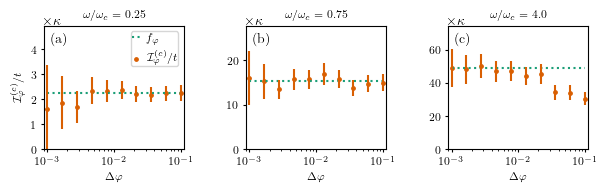

In [32]:
textwidth = 510 / 72.72  # pt -> in
fig, axs = plt.subplots(1, 3, figsize=(textwidth, 1.6))
plt.subplots_adjust(wspace=0.45)

panel_labels = ['(a)', '(b)', '(c)', '(d)']
x_line = np.logspace(-3, -1, 2)

for ax, ratio, label in zip(axs, ratios[1:4], panel_labels):
    df = df_all[df_all['ratio'] == ratio]
    ax.plot(x_line, QFI[ratio] * np.ones_like(x_line),
            color=colors[0], linestyle='dotted',
            label=r'$f_{\varphi}$')
    ax.scatter(df['deltavarphi'], df['mean_FI_rate'],
               color=colors[1], s=6,
               label=r'$\mathcal{I}^{(c)}_\varphi / t$')
    ax.errorbar(df['deltavarphi'], df['mean_FI_rate'],
                yerr=3*df['std_FI_rate'], fmt='None', color=colors[1])
    ax.set_xscale('log')
    ax.set_xlabel(r'$\Delta\varphi$')
    ax.set_xlim([0.9e-3, 1.1e-1])
    ax.tick_params(axis='both', which='major', length=2)
    ax.tick_params(axis='both', which='minor', length=1.5)
    ax.text(0.05, 0.95, label, transform=ax.transAxes,
            fontsize=10, verticalalignment='top')
    ax.set_title(rf'$\omega/\omega_c = {ratio}$', fontsize=8)
    ax.set_ylim([0, 1.2 * max(QFI[ratio], df['mean_FI_rate'].max() + 3*df['std_FI_rate'].max())])
    ax.text(0.0, 1.1, r'$\times \kappa$', transform=ax.transAxes,
            fontsize=10, verticalalignment='top')

axs[0].set_ylabel(r'$\mathcal{I}^{(c)}_\varphi / t$')
axs[0].legend(loc='best', handletextpad=0.5, handlelength=0.7)

fig.savefig('FI_sweep_vs_QFI.pdf', dpi=1000, bbox_inches='tight')
plt.show()

## Time-resolved FI rate vs long-time QFI rate

For each ratio $\omega/\omega_c$ we plot the time-resolved classical Fisher information rate $\mathcal{I}^{(c)}_\varphi /(\kappa t)$, averaged over the 1000 trajectories, with the standard deviation across trajectories shown as a shaded band. The dashed line is the long-time QFI rate $f_\varphi$ computed above.

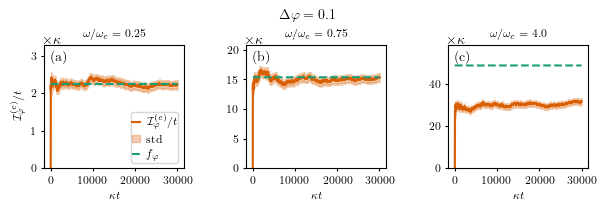

In [30]:
deltavarphi_repr = 0.1  # representative perturbation for the time-resolved trajectories

fig, axs = plt.subplots(1, 3, figsize=(textwidth, 1.6))
plt.subplots_adjust(wspace=0.45)

for ax, ratio, label in zip(axs, ratios[1:4], panel_labels):
    fname = (f'sweep_dt0.001_1000trajs/ratio_{ratio}/'
             f'time_resolved_deltavarphi_{deltavarphi_repr}.dat')
    df = pd.read_csv(fname, sep=r'\s+', header=None,
                     names=['t', 'FI', 'std'])
    df = df[df['t'] > 0]
    mean_rate = df['FI'] / df['t']
    std_rate = df['std'] / df['t']
    ax.plot(df['t'], mean_rate, color=colors[1],
            label=r'$\mathcal{I}^{(c)}_\varphi / t$')
    ax.fill_between(df['t'], mean_rate - std_rate, mean_rate + std_rate,
                    color=colors[1], alpha=0.3, label='std')
    ax.plot(df['t'], QFI[ratio] * np.ones(len(df['t'])),
            color=colors[0], linestyle='dashed', label=r'$f_\varphi$')
    ax.set_xlabel(r'$\kappa t$')
    ax.tick_params(axis='both', which='major', length=2)
    ax.tick_params(axis='both', which='minor', length=1.5)
    ax.text(0.05, 0.95, label, transform=ax.transAxes,
            fontsize=10, verticalalignment='top')
    ax.set_title(rf'$\omega/\omega_c = {ratio}$', fontsize=8)
    ax.set_ylim([0, 1.2 * max(QFI[ratio], mean_rate.max() + std_rate.max())])
    ax.text(0.0, 1.1, r'$\times \kappa$', transform=ax.transAxes,
            fontsize=10, verticalalignment='top')

axs[0].set_ylabel(r'$\mathcal{I}^{(c)}_\varphi / t$')
axs[0].legend(loc='best', handletextpad=0.5, handlelength=0.7)

fig.suptitle(rf'$\Delta\varphi = {np.floor(deltavarphi_repr * 10000) / 10000}$', fontsize=10, y=1.1)

fig.savefig(f'FI_trajectories_vs_QFI_dphi_{np.floor(deltavarphi_repr * 10000) / 10000}.pdf', dpi=1000, bbox_inches='tight')
plt.show()